# Лабораторная работа 1
### "Классификация новостей"

Цель работы: создать НС, которая определяет категорию новости (спорт, IT, бизнес, преступления).

## 1. Установка библиотек

In [2]:
!pip install torch==2.3.0 torchtext==0.18.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.1/779.1 MB 703.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Загрузка датасета

Загружаем CSV-файл с новостями. Файл должен содержать столбцы с текстом новости и её категорией. Я загрузила датасет себе на диск и сделала загрузку с него для удобства

In [3]:
import gdown

url = f"https://drive.google.com/uc?id=1Xn7ooFCZIKxfjwb83X-WOfnXEixQm1Hz"
output = "ag_news.csv"

gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1Xn7ooFCZIKxfjwb83X-WOfnXEixQm1Hz
To: /content/ag_news.csv
100%|██████████| 30.2M/30.2M [00:00<00:00, 64.1MB/s]


'ag_news.csv'

In [4]:
import pandas as pd

data = pd.read_csv('ag_news.csv', sep=';')
print(data.head())

   category                                            content
0        IT   webify helps insurance carriers stretch legac...
1  business   update 1 thursday #39 s commodities roundup ,...
2  business   california regulator is suing four insurers a...
3     crime   mexico fta paves way for asian trade agreemen...
4     sport   t amp t , costa rica through , angus eve scor...


## 3. Предобработка данных

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   category  120000 non-null  object
 1   content   120000 non-null  object
dtypes: object(2)
memory usage: 1.8+ MB


Нам очень повезло, в данных нет пропусков

In [6]:
TEXT_COL = 'content'
LABEL_COL = 'category'

Переводим категории в числовой формат

In [7]:
data[LABEL_COL] = data[LABEL_COL].astype('category')
print("Категории:", dict(enumerate(data[LABEL_COL].cat.categories)))
data[LABEL_COL] = data[LABEL_COL].cat.codes

Категории: {0: 'IT', 1: 'business', 2: 'crime', 3: 'sport'}


In [8]:
print(data[LABEL_COL].value_counts())

category
0    30000
1    30000
2    30000
3    30000
Name: count, dtype: int64


Опять сказочно повезло, нет дисбаланса классов еее

## 4. Разделение данных на тренировочные, валидационные и тестовые

In [9]:
from sklearn.model_selection import train_test_split

X = data[TEXT_COL]
y = data[LABEL_COL]

data_train, data_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# из оставшихся 80% отделяем валидацию (15% от всех данных = 18.75% от data_train)
data_train, data_val, y_train, y_val = train_test_split(
    data_train, y_train, test_size=0.1875, random_state=42  # 0.1875 * 0.8 = 0.15
)

print(f"Тренировочных примеров: {len(data_train)}")
print(f"Валидационных примеров: {len(data_val)}")
print(f"Тестовых примеров: {len(data_test)}")

Тренировочных примеров: 78000
Валидационных примеров: 18000
Тестовых примеров: 24000


## 5. Создание словаря (vocab)

Строим словарь по тренировочным данным, разбивая текст на слова (токены).

In [10]:
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
import torchtext
torchtext.disable_torchtext_deprecation_warning() # токенизатор ругался, там что-то устарело

# tokenizer разбивает строку на слова и приводит к нижнему регистру
tokenizer = get_tokenizer('basic_english')

def yield_tokens(texts):
    for text in texts:
        yield tokenizer(text) # yield возращает каждый раз tokenizer(text)

# Строим словарь только по тренировочным данным, тестовые мы не знаем, валидационные тоже
vocab = build_vocab_from_iterator(yield_tokens(data_train), specials=["<unk>"])
vocab.set_default_index(vocab["<unk>"])  # неизвестным словам присваивается индекс 0

print(f"Размер словаря: {len(vocab)}")

/usr/local/lib/python3.12/dist-packages/torchtext/data/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/usr/local/lib/python3.12/dist-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated

Размер словаря: 78225


Посмотим, нет ли сильного разброса по токенам в тесте, вале и трейне.

In [11]:
# Функция анализа покрытия. Анализирует, какой процент токенов известен словарю
def analyze_coverage(texts, vocab):
    total_tokens = 0
    known_tokens = 0
    unknown_tokens = 0
    unique_unknown = set()

    for text in texts:
        if pd.isna(text) or str(text).strip() == '':
            empty_texts += 1
            continue

        tokens = tokenizer(str(text))
        for token in tokens:
            total_tokens += 1
            if token in vocab:
                known_tokens += 1
            else:
                unknown_tokens += 1
                unique_unknown.add(token)

    known_percentage = (known_tokens / total_tokens) * 100 if total_tokens > 0 else 0
    unknown_percentage = (unknown_tokens / total_tokens) * 100 if total_tokens > 0 else 0

    return {
        'total_tokens': total_tokens,
        'known_tokens': known_tokens,
        'unknown_tokens': unknown_tokens,
        'known_percentage': known_percentage,
        'unknown_percentage': unknown_percentage,
        'unique_known': len(vocab),
        'unique_unknown': len(unique_unknown)
    }


test_stats = analyze_coverage(data_test, vocab)
print(f"Всего токенов в тесте: {test_stats['total_tokens']:,}")
print(f"Известных токенов: {test_stats['known_tokens']:,} ({test_stats['known_percentage']:.2f}%)")
print(f"Неизвестных токенов: {test_stats['unknown_tokens']:,} ({test_stats['unknown_percentage']:.2f}%)")
print(f"Размер словаря (уникальных слов в тренировке): {test_stats['unique_known']:,}")
print(f"Уникальных неизвестных слов в тесте: {test_stats['unique_unknown']:,}")

Всего токенов в тесте: 1,063,671
Известных токенов: 1,051,592 (98.86%)
Неизвестных токенов: 12,079 (1.14%)
Размер словаря (уникальных слов в тренировке): 78,225
Уникальных неизвестных слов в тесте: 10,508


У нас всё отлично, 98.86%

## 6. Класс Dataset и загрузчики данных

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader

class NewsDataset(Dataset):
    def __init__(self, data_text, labels):
        self.data = data_text.reset_index(drop=True) # сбрасывает индексы и создает новую нумерацию строк с 0
        self.y = labels.reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Разбиваем текст на слова (tokenizer вместо list)
        text = vocab(tokenizer(self.data[idx]))
        return torch.tensor(text, dtype=torch.int64), torch.tensor(self.y[idx], dtype=torch.int64)

In [13]:
def collate_batch(batch):
    """Собирает батч: выравнивает тексты разной длины через EmbeddingBag offsets."""
    label_list, text_list, offsets = [], [], [0]
    for (_text, _label) in batch:
        label_list.append(_label)
        processed_text = _text.clone().detach()
        text_list.append(processed_text)
        offsets.append(processed_text.size(0))
    label_list = torch.tensor(label_list, dtype=torch.int64)
    offsets = torch.tensor(offsets[:-1]).cumsum(dim=0)
    text_list = torch.cat(text_list)
    return label_list, text_list, offsets

In [14]:
trainset = NewsDataset(data_train, y_train)
valset = NewsDataset(data_val, y_val)
testset  = NewsDataset(data_test,  y_test)

trainloader = DataLoader(trainset, batch_size=16, shuffle=True,  collate_fn=collate_batch)
valloader = DataLoader(valset, batch_size=16, shuffle=False, collate_fn=collate_batch)
testloader  = DataLoader(testset,  batch_size=16, shuffle=False, collate_fn=collate_batch)

## 7. Архитектура нейросети

Используем `EmbeddingBag` для преобразования слов в векторы, затем два полносвязных слоя с активацией ReLU.

In [36]:
from torch import nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_class  = len(set(y_train))   # количество категорий (4)
vocab_size = len(vocab)          # размер словаря
embed_dim  = 128                  # размерность эмбеддинга

print(f"Кол-во классов: {num_class}")
print(f"Размер словаря: {vocab_size}")

class NewsClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_class):
        super(NewsClassifier, self).__init__()
        self.embedding = nn.EmbeddingBag(vocab_size, embed_dim, sparse=False)

        self.fc1 = nn.Linear(embed_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)

        self.fc3 = nn.Linear(64, num_class)

        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)   # после первого слоя
        self.dropout2 = nn.Dropout(0.3)   # после второго слоя
        self.dropout3 = nn.Dropout(0.2)   # перед выходом (меньше)

    def forward(self, text, offsets):
        x = self.embedding(text, offsets)

        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)

        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)

        x = self.relu(self.fc3(x))
        x = self.dropout3(x)   # dropout перед выходом

        return x


net = NewsClassifier(vocab_size, embed_dim, num_class).to(device)

criterion = nn.CrossEntropyLoss().to(device)        # log loss для многоклассовой классификации

import torch.optim as optim
optimizer = optim.AdamW(net.parameters(), lr=0.0005, weight_decay=1e-4)  # Adam — адаптивный оптимизатор, weight_decay=1e-4 это Loss_общая = Loss_оригинальная + weight_decay * сумма_квадратов_весов, региляризация такая

print(net)

Кол-во классов: 4
Размер словаря: 78225
NewsClassifier(
  (embedding): EmbeddingBag(78225, 128, mode='mean')
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=4, bias=True)
  (relu): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (dropout2): Dropout(p=0.3, inplace=False)
  (dropout3): Dropout(p=0.2, inplace=False)
)


## 8. Обучение нейросети

In [34]:
# @title
import matplotlib.pyplot as plt
from IPython.display import clear_output

def plot_history(history, epoch):
    """
    Строит графики loss и accuracy на текущий момент обучения,
    стирая предыдущие графики

    Args:
        history: dict с ключами 'train_loss', 'val_loss', 'train_acc', 'val_acc'
        epoch: текущий номер эпохи (для заголовка)
    """
    # Очищаем вывод предыдущего графика
    clear_output(wait=True)

    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # График потерь (Loss)
    ax1.plot(epochs, history['train_loss'], label='Train Loss', marker='o', color='blue', linewidth=2)
    ax1.plot(epochs, history['val_loss'], label='Validation Loss', marker='s', color='red', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title(f'Loss over epochs (Epoch {epoch})', fontsize=14)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # График точности (Accuracy)
    ax2.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o', color='blue', linewidth=2)
    ax2.plot(epochs, history['val_acc'], label='Validation Accuracy', marker='s', color='red', linewidth=2)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title(f'Accuracy over epochs (Epoch {epoch})', fontsize=14)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

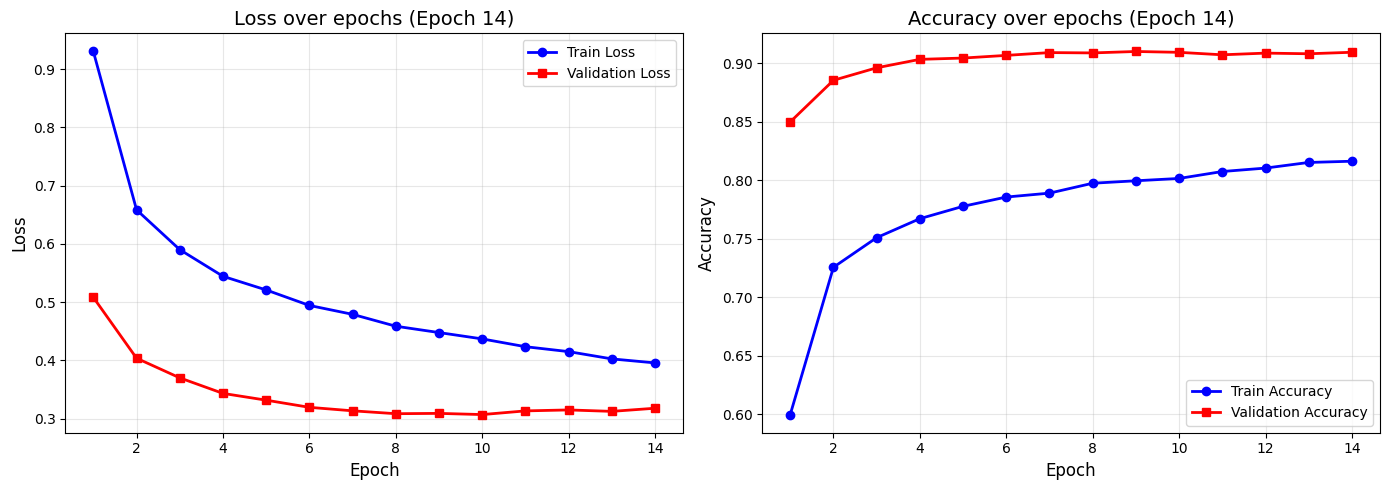


Epoch [14/20]
  Train Loss: 0.3956 | Train Acc: 0.8162
  Val Loss:   0.3178 | Val Acc:   0.9093
  -> Early stopping triggered!

Обучение завершено!
Best validation accuracy: 0.9099


In [37]:
NUM_EPOCHS = 20
best_val_acc = 0.0
patience = 5
patience_counter = 0

# Словари для сохранения истории метрик
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

net.train(True)
for epoch in range(NUM_EPOCHS):
    # Training phase
    running_loss = 0.0
    running_corrects = 0.0
    total_batches = 0

    for labels, inputs, offsets in trainloader:
        labels = labels.to(device)
        inputs = inputs.to(device)
        offsets = offsets.to(device)

        optimizer.zero_grad()
        outputs = net(inputs, offsets)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_corrects += (preds == labels).float().mean().item()
        total_batches += 1

    train_loss = running_loss / total_batches
    train_acc = running_corrects / total_batches

    # Сохраняем тренировочные метрики
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)

    # Validation phase
    net.eval()
    val_loss = 0.0
    val_corrects = 0.0
    val_batches = 0

    with torch.no_grad():
        for labels, inputs, offsets in valloader:
            labels = labels.to(device)
            inputs = inputs.to(device)
            offsets = offsets.to(device)

            outputs = net(inputs, offsets)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_corrects += (preds == labels).float().mean().item()
            val_batches += 1

    val_loss = val_loss / val_batches
    val_acc = val_corrects / val_batches

    # Сохраняем валидационные метрики
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

     # Строим графики после каждой эпохи
    plot_history(history, epoch+1)

    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(net.state_dict(), 'best_model.pt')
        patience_counter = 0
        print(f"  -> New best model saved!")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  -> Early stopping triggered!")
            break

    net.train(True)

print('\nОбучение завершено!')
print(f"Best validation accuracy: {best_val_acc:.4f}")

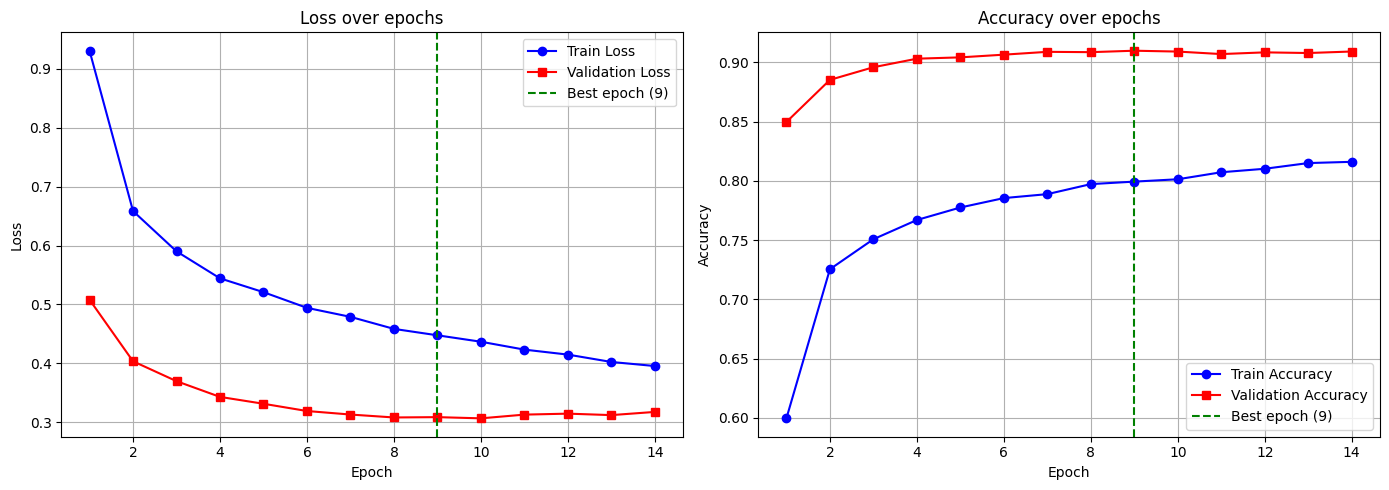

In [38]:
# Финальный график с маркерами лучшей эпохи
def plot_final_with_best(history, best_epoch):
    """Финальный график с выделением лучшей эпохи"""
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history['train_loss'], label='Train Loss', marker='o', color='blue')
    ax1.plot(epochs, history['val_loss'], label='Validation Loss', marker='s', color='red')
    ax1.axvline(x=best_epoch, color='green', linestyle='--', label=f'Best epoch ({best_epoch})')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss over epochs')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o', color='blue')
    ax2.plot(epochs, history['val_acc'], label='Validation Accuracy', marker='s', color='red')
    ax2.axvline(x=best_epoch, color='green', linestyle='--', label=f'Best epoch ({best_epoch})')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy over epochs')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Находим лучшую эпоху (с максимальной val_acc)
best_epoch = history['val_acc'].index(max(history['val_acc'])) + 1
plot_final_with_best(history, best_epoch)

## 9. Тестирование нейросети

In [42]:
from sklearn.metrics import classification_report, confusion_matrix

net.train(False)

correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for labels, inputs, offsets in testloader:
        labels = labels.to(device)
        inputs = inputs.to(device)
        offsets = offsets.to(device)

        outputs = net(inputs, offsets)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


accuracy = correct / total
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

Accuracy: 0.9103 (91.03%)


In [43]:
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=['IT', 'business', 'crime', 'sport']))


Classification Report:
              precision    recall  f1-score   support

          IT       0.88      0.88      0.88      6038
    business       0.88      0.89      0.88      6064
       crime       0.93      0.89      0.91      5962
       sport       0.95      0.98      0.96      5936

    accuracy                           0.91     24000
   macro avg       0.91      0.91      0.91     24000
weighted avg       0.91      0.91      0.91     24000



*   Precision: из предсказанных как класс X — сколько реально X
*   Recall: из реальных X — сколько модель нашла
*   F1-score: среднее гармоническое между precision и recall

## 10. Проверка на отдельном примере

In [40]:
# Словарь категорий (восстанавливаем из исходных данных)
original_data = pd.read_csv('ag_news.csv', sep=';').dropna(subset=[TEXT_COL, LABEL_COL])
categories = dict(enumerate(original_data[LABEL_COL].astype('category').cat.categories))
print("Категории:", categories)

def predict(text):
    net.train(False)
    with torch.no_grad():
        tokens = torch.tensor(vocab(tokenizer(text)), dtype=torch.int64, device=device)
        offsets = torch.tensor([0], device=device)
        output = net(tokens, offsets)
        _, pred = torch.max(output, 1)
        return categories[pred.item()]

# Пример
sample_text = "The team scored three goals in the championship match"
print(f"\nТекст: {sample_text}")
print(f"Предсказанная категория: {predict(sample_text)}")

Категории: {0: 'IT', 1: 'business', 2: 'crime', 3: 'sport'}

Текст: The team scored three goals in the championship match
Предсказанная категория: sport
